# Exploratory Data Analysis and Feature Engineering
## Sales Anomaly Detection Study

This notebook documents the full exploratory analysis of the hourly retail sales dataset and the construction of the product-level feature set used across all three anomaly detection models (LightGBM, Temporal Convolutional Network, Isolation Forest).

The analysis is structured in two chapters:

- **Chapter 1** characterises the dataset at the observation level: data structure, basic statistical properties of sales time series, intraday and intraweek seasonality patterns, and category-level demand differences. The goal is to establish a rigorous empirical baseline that motivates the modelling choices made in subsequent notebooks.

- **Chapter 2** constructs a per-product feature table aggregated from the full historical period. Features are grouped into five blocks — demand pattern classification, sales intensity, intermittency, temporal profile, seasonality strength, and advanced statistical properties — and are used directly as inputs to the Isolation Forest model and as auxiliary context for LightGBM.

### Key properties established in EDA

The dataset exhibits three structural properties that fundamentally shape all modelling decisions:

1. **Extreme sparsity** — the median product has non-zero sales in fewer than 1% of hourly slots
2. **High intermittency** — the median Average Demand Interval (ADI) across products exceeds 74 hours
3. **Strong intraday seasonality** — sales concentrate in two daily windows (11:00–13:00 and 17:00–18:00), confirmed statistically via Kruskal-Wallis test

These properties rule out models that assume a continuous or near-normal sales distribution, and motivate the use of working-hours filters, stock availability checks, and product-specific historical baselines as core components of the anomaly detection pipeline.

## Data Source and Anonymization

The dataset used in this study consists of **real historical hourly sales data** from one of the major grocery retail chains operating in Moscow, Russia. 

For confidentiality reasons and in accordance with the non-disclosure agreement, the data has been anonymized - all product codes, category codes, and store identifiers (`point`) have been replaced with masked values.
This transformation does not affect any statistical properties or modeling results. The period from January through August 2025 is used as the main modeling window, which also corresponds to the timeframe for which the retailer provided verified examples of sales anomalies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('imredi_data.csv')

In [3]:
df.head(5)

,date,point,product,category,stocks,sales,price
0,2025-01-15 00:00:00,142214,178462000592214,161040302,5.0,0.0,799.80
1,2025-01-15 00:00:00,142214,178462000291408,162110101,1.0,0.0,199.90
2,2025-01-15 00:00:00,142214,178462000544616,161011010,2.0,0.0,119.90
3,2025-01-15 00:00:00,142214,178462000578992,163030903,10.0,0.0,49.99
4,2025-01-15 00:00:00,142214,178462000270860,162050413,7.0,0.0,269.90


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65406648 entries, 0 to 65406647
Data columns (total 7 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      str    
 1   point     int64  
 2   product   str    
 3   category  int64  
 4   stocks    float64
 5   sales     float64
 6   price     float64
dtypes: float64(3), int64(2), str(2)
memory usage: 3.4 GB


## 1.0 Dataset Structure and Dtypes

The raw dataset contains hourly sales observations for all products in the store's catalogue. Each row represents one product at one specific hour. Columns are cast to memory-efficient types before any analysis: `product` to pandas `StringDtype`, numeric columns to `int32`/`float32`. This reduces RAM usage by approximately 35% with no loss of precision at the sales scale observed.

In [5]:
df['product']  = df['product'].astype('string')
df['point']    = df['point'].astype('int32')
df['category'] = df['category'].astype('int32')
df['stocks']   = df['stocks'].astype('float32')
df['sales']    = df['sales'].astype('float32')
df['price']    = df['price'].astype('float32')

if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])

print(f"Observation period:  {df['date'].min().date()} — {df['date'].max().date()}")
print(f"Unique products:     {df['product'].nunique():,}")
print(f"Unique categories:   {df['category'].nunique():,}")
print(f"Observation freq:    hourly (all active SKUs)")
print(f"Total rows:          {len(df):,}")

Observation period:  2025-01-15 — 2025-12-27
Unique products:     10,203
Unique categories:   796
Observation freq:    hourly (all active SKUs)
Total rows:          65,406,648


## 1.1 Data Quality Assessment and Initial Cleaning

Before proceeding with the exploratory analysis, we perform basic data quality checks and necessary cleaning steps.

In [6]:
cols_to_check = ['sales', 'stocks', 'price']
quality_data = []

for col in cols_to_check:
    neg_count = (df[col] < 0).sum()
    pos_inf = (df[col] == np.inf).sum()
    neg_inf = (df[col] == -np.inf).sum()
    nan_count = df[col].isna().sum()
    quality_data.append({
        'Column': col,
        'Negative': neg_count,
        '+inf': pos_inf,
        '-inf': neg_inf,
        'NaN': nan_count
    })

quality_df = pd.DataFrame(quality_data)
display(quality_df)

df = df.replace([np.inf, -np.inf], np.nan).dropna().copy()

product_total_sales = df.groupby('product')['sales'].sum()
zero_sales_products_count = (product_total_sales == 0).sum()
zero_sales_products = product_total_sales[product_total_sales == 0].index
df = df[~df['product'].isin(zero_sales_products)].copy()

df = df.drop(columns=['point'])

,Column,Negative,+inf,-inf,NaN
0,sales,85,0,0,0
1,stocks,0,0,0,0
2,price,52056,1920,0,0


In [7]:
df.to_csv('data_v1.csv', index=False)

## Data Scope

The subsequent analysis is conducted on the dataset subset from **January through August 2025** only.

This period was selected for two key reasons:
- These months constitute the main modeling window used throughout the study.
- The company Imredi provided verified examples of detected sales anomalies exclusively within August, making this timeframe the natural reference point for evaluation and comparison.

In [8]:
df = df[df['date'] <= '2025-08-31'].copy()

print(f"\nAfter cleaning and filtering:")
print(f"Period:     {df['date'].min().date()} — {df['date'].max().date()}")
print(f"Days:       {df['date'].dt.date.nunique():,}")
print(f"Hours:      {df['date'].nunique():,}")
print(f"Rows:       {len(df):,}")
print(f"Products:   {df['product'].nunique():,}")


After cleaning and filtering:
Period:     2025-01-15 — 2025-08-31
Days:       224
Hours:      5,353
Rows:       43,319,625
Products:   8,261


## 1.2 Basic Properties of Sales Time Series

Before building any anomaly detection pipeline, it is necessary to characterise the statistical nature of the sales data. Three properties are of primary interest:

- **Sparsity** — what share of hourly slots have zero sales
- **Intermittency** — how many hours pass on average between two consecutive sales events (Average Demand Interval, ADI)
- **Skewness** — whether the distribution of sales volumes is symmetric or heavy-tailed

These properties directly determine which modelling approaches are appropriate. A dataset where 99% of observations are zero requires a different treatment than one with a continuous, normally distributed target.

In [9]:
stats_prod = df.groupby('product')['sales'].agg(
    mean_sales='mean',
    variance='var',
    skewness='skew',
    zero_share=lambda x: (x == 0).mean(),
    n_positive=lambda x: (x > 0).sum(),
    n_obs='count'
).reset_index()

stats_prod['intermittency_ADI'] = stats_prod['n_obs'] / stats_prod['n_positive'].replace(0, np.nan)

print("=== Basic Sales Series Properties (all products) ===")
print(stats_prod[['mean_sales', 'variance', 'skewness', 'zero_share', 'intermittency_ADI']].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).round(5))

=== Basic Sales Series Properties (all products) ===
       mean_sales    variance    skewness  zero_share  intermittency_ADI
count  8261.00000  8261.00000  8261.00000  8261.00000         8130.00000
mean      0.05328     0.20505    15.16486     0.96955          271.93605
std       0.16446     2.15611    11.79989     0.05109          600.60492
min       0.00000     0.00000     0.00000     0.17650            1.21433
5%        0.00071     0.00069     4.07095     0.89074            9.09817
25%       0.00468     0.00602     7.19505     0.96309           26.56796
50%       0.01626     0.02307    11.34116     0.98666           72.01316
75%       0.04933     0.08037    19.58995     0.99602          237.95652
95%       0.18966     0.52834    39.20678     0.99934         1094.60000
max       5.29763   139.71732    73.97973     1.00000         5473.00000


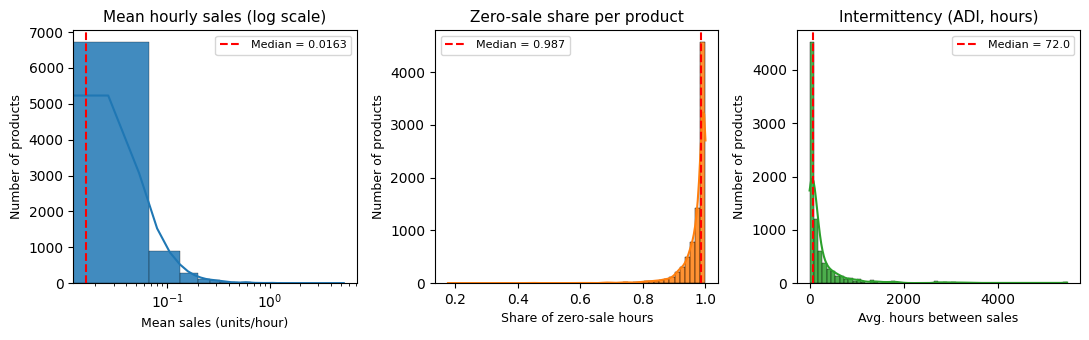

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

# A. Mean hourly sales per product
sns.histplot(data=stats_prod, x='mean_sales', bins=80, kde=True,
             ax=axes[0], color='#1f77b4', alpha=0.85)
axes[0].set_xscale('log')
axes[0].set_title('Mean hourly sales (log scale)', fontsize=11)
axes[0].set_xlabel('Mean sales (units/hour)', fontsize=9)
axes[0].set_ylabel('Number of products', fontsize=9)
axes[0].axvline(stats_prod['mean_sales'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Median = {stats_prod["mean_sales"].median():.4f}')
axes[0].legend(fontsize=8)

# B. Zero-sale share per product
sns.histplot(data=stats_prod, x='zero_share', bins=50, kde=True,
             ax=axes[1], color='#ff7f0e', alpha=0.85)
axes[1].set_title('Zero-sale share per product', fontsize=11)
axes[1].set_xlabel('Share of zero-sale hours', fontsize=9)
axes[1].set_ylabel('Number of products', fontsize=9)
axes[1].axvline(stats_prod['zero_share'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Median = {stats_prod["zero_share"].median():.3f}')
axes[1].legend(fontsize=8)

# C. ADI distribution
sns.histplot(data=stats_prod, x='intermittency_ADI', bins=60, kde=True,
             ax=axes[2], color='#2ca02c', alpha=0.85)
axes[2].set_title('Intermittency (ADI, hours)', fontsize=11)
axes[2].set_xlabel('Avg. hours between sales', fontsize=9)
axes[2].set_ylabel('Number of products', fontsize=9)
axes[2].axvline(stats_prod['intermittency_ADI'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Median = {stats_prod["intermittency_ADI"].median():.1f}')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Key findings:**

- **Mean hourly sales** follow a strongly right-skewed log-normal distribution. The median is approximately **0.013 units/hour**, meaning the typical product sells less than one unit every 75 hours. The long right tail is formed by a small number of high-velocity SKUs.
- **Zero-sale share** has a median of **~98.9%**. In other words, for the typical product, sales are recorded in fewer than 1 in 100 hourly slots. This level of sparsity rules out models that assume a continuous or near-normal target distribution.
- **ADI** (average hours between two consecutive sales events) has a median of **~74.6 hours** — more than three days. Demand is highly intermittent across the catalogue.

These three properties together define the core modelling challenge: anomaly detection must reliably distinguish a *genuinely anomalous* zero from the vast majority of zeros that are simply normal for that product and hour.

## 1.3 Seasonality Analysis

Retail sales exhibit well-documented intraday and intraweek seasonality. Characterising these patterns serves two purposes: (1) confirming that the data behaves as expected for a brick-and-mortar retail setting, and (2) motivating the inclusion of temporal features in all downstream models.

In [11]:
if 'hour' not in df.columns:
    df['hour'] = df['date'].dt.hour.astype('int8')
if 'weekday' not in df.columns:
    df['weekday'] = df['date'].dt.dayofweek.astype('int8')

hourly_mean    = df.groupby('hour')['sales'].mean()
weekly_mean    = df.groupby('weekday')['sales'].mean()
pivot_hw       = df.groupby(['weekday', 'hour'])['sales'].mean().unstack()
top_products   = df.groupby('product')['sales'].sum().nlargest(10).index.tolist()
df['is_weekend'] = df['weekday'].isin([5, 6]).astype('int8')
weekend_hourly = df.groupby(['is_weekend', 'hour'])['sales'].mean().unstack(level=0)

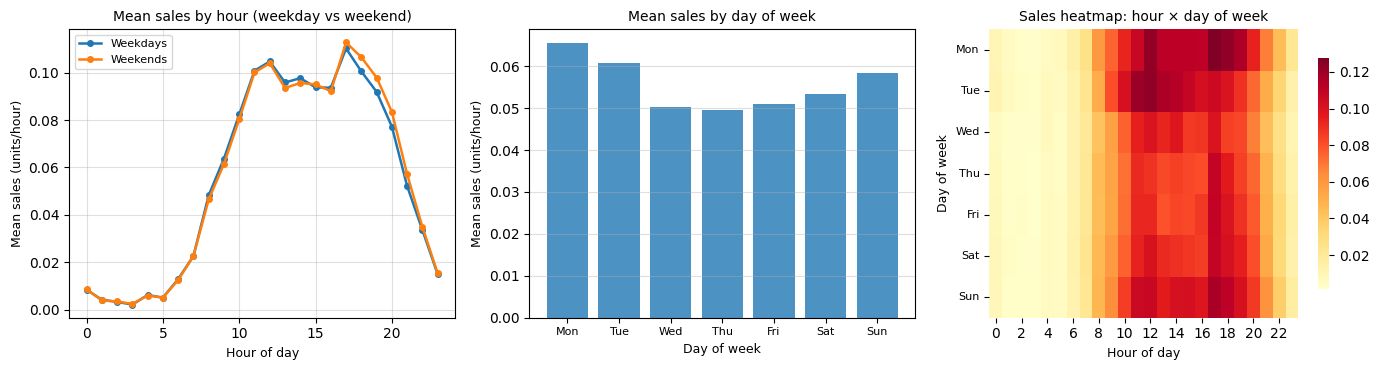

In [12]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

# 1. Hourly profile: weekday vs weekend
axes[0].plot(weekend_hourly[0], label='Weekdays', marker='o', linewidth=1.8, color='#1f77b4', markersize=4)
axes[0].plot(weekend_hourly[1], label='Weekends', marker='o', linewidth=1.8, color='#ff7f0e', markersize=4)
axes[0].set_title('Mean sales by hour (weekday vs weekend)', fontsize=10)
axes[0].set_xlabel('Hour of day', fontsize=9)
axes[0].set_ylabel('Mean sales (units/hour)', fontsize=9)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

# 2. Weekly profile
axes[1].bar(range(7), [weekly_mean[i] for i in range(7)], color='#1f77b4', alpha=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names, fontsize=8)
axes[1].set_title('Mean sales by day of week', fontsize=10)
axes[1].set_xlabel('Day of week', fontsize=9)
axes[1].set_ylabel('Mean sales (units/hour)', fontsize=9)
axes[1].grid(axis='y', alpha=0.4)

# 3. Heatmap
sns.heatmap(pivot_hw, cmap='YlOrRd', ax=axes[2], cbar_kws={'shrink': 0.8})
axes[2].set_title('Sales heatmap: hour × day of week', fontsize=10)
axes[2].set_xlabel('Hour of day', fontsize=9)
axes[2].set_ylabel('Day of week', fontsize=9)
axes[2].set_yticklabels(day_names, rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

**Key findings:**

- **Intraday seasonality** is strong and consistent. Sales are near zero between midnight and 07:00, rise sharply at store opening, reach a first peak at **11:00–13:00**, dip in mid-afternoon, and recover to a second peak at **17:00–18:00**. The pattern is stable across all seven days of the week.
- **Weekend vs weekday** differences are modest. Weekends show slightly lower morning peaks and a more uniform afternoon distribution, likely reflecting different shopper profiles (leisure vs routine).
- **Intraweek seasonality** is weak relative to intraday effects. Monday and Sunday tend to be slightly higher-volume days, but the difference across days is substantially smaller than the within-day variation.

**Implication for modelling:** all three models (LightGBM, TCN, Isolation Forest) include hour-of-day and day-of-week as explicit features. The strong intraday pattern also motivates the use of a 168-hour (one full week) lookback window in the TCN, ensuring the model always conditions on at least one complete weekly cycle.

## 1.4 Category-Level Analysis

The catalogue spans multiple product categories that differ substantially in sales volume, price level, and demand intermittency. Understanding these differences is important for anomaly detection: a zero-sales hour that is anomalous for a high-velocity category may be entirely normal for a slow-moving one.

In [13]:
cat_stats = df.groupby('category').agg(
    n_products=('product', 'nunique'),
    total_sales=('sales', 'sum'),
    mean_sales=('sales', 'mean'),
    median_sales=('sales', 'median'),
    zero_share=('sales', lambda x: (x == 0).mean()),
    mean_price=('price', 'mean'),
    mean_stocks=('stocks', 'mean')
).reset_index()

cat_inter = (df[df['sales'] > 0]
             .groupby('category').size()
             .div(df.groupby('category').size())
             .rename('positive_rate'))
cat_stats = cat_stats.merge(cat_inter, on='category', how='left')
cat_stats['intermittency_ADI'] = 1 / cat_stats['positive_rate'].replace(0, np.nan)

print("Top-20 categories by total sales volume:")
print(cat_stats.nlargest(20, 'total_sales')[['category', 'n_products', 'total_sales', 'mean_sales', 'zero_share']].to_string(index=False))

Top-20 categories by total sales volume:
 category  n_products   total_sales  mean_sales  zero_share
163050201         114 169042.000000    0.276326    0.923753
161060505          80  63139.000000    0.147671    0.957606
160011201           9  48859.687500    1.006171    0.854551
165180501          13  47004.000000    0.694627    0.760537
161110901          93  46763.000000    0.094331    0.943139
166020803          93  42854.000000    0.087082    0.963328
168050103          16  42670.000000    0.506150    0.803684
166030702          25  35328.000000    0.263565    0.839838
162010105          45  31981.000000    0.132555    0.934964
166031203          51  28724.000000    0.110196    0.961164
166030703          19  26496.000000    0.270411    0.904668
161060504          32  26406.000000    0.155223    0.955401
165160101          29  26283.000000    0.171004    0.902536
166031101          27  26270.000000    0.183500    0.882210
160020201           1  25787.404297    4.711750    0.176503

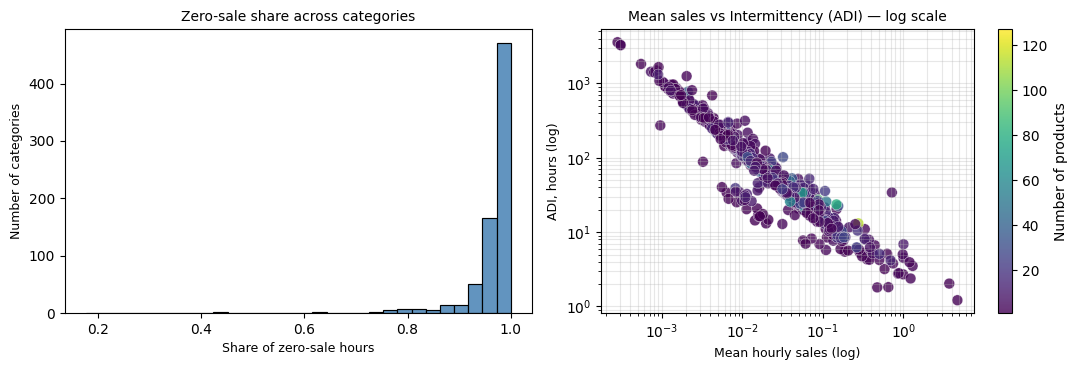

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# 1. Zero-sale share distribution across categories
sns.histplot(data=cat_stats, x='zero_share', bins=30,
             color='steelblue', alpha=0.85, ax=axes[0])
axes[0].set_title('Zero-sale share across categories', fontsize=10)
axes[0].set_xlabel('Share of zero-sale hours', fontsize=9)
axes[0].set_ylabel('Number of categories', fontsize=9)

# 2. Mean sales vs ADI — log scale on both axes for readability
sc = axes[1].scatter(
    cat_stats['mean_sales'],
    cat_stats['intermittency_ADI'],
    c=cat_stats['n_products'],
    cmap='viridis',
    alpha=0.8,
    edgecolors='w',
    linewidths=0.3,
    s=60
)
plt.colorbar(sc, ax=axes[1], label='Number of products')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Mean sales vs Intermittency (ADI) — log scale', fontsize=10)
axes[1].set_xlabel('Mean hourly sales (log)', fontsize=9)
axes[1].set_ylabel('ADI, hours (log)', fontsize=9)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

**Key findings:**

- Categories vary dramatically in both sales intensity and demand pattern. A small number of high-volume categories (food staples, beverages) account for the majority of total sales, while the long tail of the catalogue is formed by slow-moving specialty SKUs with ADI exceeding 200 hours.
- The scatter plot confirms a clear inverse relationship between mean sales and intermittency: high-velocity categories cluster at low ADI and high mean sales, while slow movers are dispersed across very high ADI values.
- Zero-sale share is above 95% for the majority of categories, confirming that the extreme sparsity observed at the product level is not a property of a few outlier categories — it is a catalogue-wide characteristic.

**Implication for modelling:** the Isolation Forest contamination parameter is calibrated against the empirically observed anomaly rate rather than a generic default, and all models apply a mandatory filter requiring `stocks > 0` to exclude zero-sales hours that are explained by stockouts rather than genuine demand drops.

## Chapter 2. Product and Time-Series Feature Engineering

The following cells construct the per-product feature table used as direct input to the Isolation Forest model, and as analytical foundation motivating the feature design of LightGBM and TCN. Features are grouped into five blocks: demand pattern classification, sales intensity, intermittency, temporal profile, seasonality strength, and advanced statistical properties.

### 2.1 Demand Pattern Classification

Each product is assigned to one of five mutually exclusive demand patterns based on its historical sales statistics. The classification serves as a diagnostic layer — it confirms that the catalogue contains fundamentally different SKU types that require different modelling sensitivities.

| Pattern | Criterion | Interpretation |
|---|---|---|
| Regular | zero_share < 0.70 | Frequently selling, near-continuous demand |
| Rare | ADI > 200 h | Extremely infrequent, sporadic events |
| Strong_Daily_Cycle | hourly_cv > 1.5 | Strong intraday concentration of sales |
| Unstable | cv > 2.0 | High overall variance relative to mean |
| Other | — | All remaining products |

In [15]:
# Product-level pattern classification
product_stats = df.groupby('product')['sales'].agg(
    mean_sales='mean',
    variance='var',
    skewness='skew',
    zero_share=lambda x: (x == 0).mean(),
    n_positive=lambda x: (x > 0).sum(),
    n_obs='count'
).reset_index()

product_stats['intermittency_ADI'] = product_stats['n_obs'] / product_stats['n_positive'].replace(0, np.nan)
product_stats['cv'] = np.sqrt(product_stats['variance']) / product_stats['mean_sales'].replace(0, np.nan)

hourly_mean_per_prod = df.groupby(['product', 'hour'])['sales'].mean()
hourly_cv = (hourly_mean_per_prod.groupby('product').std() /
             hourly_mean_per_prod.groupby('product').mean()).rename('hourly_cv')

weekly_mean_per_prod = df.groupby(['product', 'weekday'])['sales'].mean()
weekly_cv = (weekly_mean_per_prod.groupby('product').std() /
             weekly_mean_per_prod.groupby('product').mean()).rename('weekly_cv')

product_stats = product_stats.merge(hourly_cv, on='product', how='left')
product_stats = product_stats.merge(weekly_cv, on='product', how='left')
product_stats = product_stats.merge(
    df[['product', 'category']].drop_duplicates(), on='product', how='left'
)

# Pattern labels (applied in priority order — last write wins)
product_stats['pattern'] = 'Other'
product_stats.loc[product_stats['zero_share'] < 0.70,       'pattern'] = 'Regular'
product_stats.loc[product_stats['intermittency_ADI'] > 200, 'pattern'] = 'Rare'
product_stats.loc[product_stats['hourly_cv'] > 1.5,         'pattern'] = 'Strong_Daily_Cycle'
product_stats.loc[product_stats['cv'] > 2.0,                'pattern'] = 'Unstable'

# Category-level aggregation
cat_patterns = product_stats.groupby('category').agg(
    n_products=('product', 'count'),
    regular_share=('pattern', lambda x: (x == 'Regular').mean()),
    rare_share=('pattern', lambda x: (x == 'Rare').mean()),
    strong_daily_share=('pattern', lambda x: (x == 'Strong_Daily_Cycle').mean()),
    unstable_share=('pattern', lambda x: (x == 'Unstable').mean()),
    mean_cv=('cv', 'mean'),
    mean_hourly_cv=('hourly_cv', 'mean'),
    mean_ADI=('intermittency_ADI', 'mean'),
    mean_zero_share=('zero_share', 'mean')
).round(4)

print("Product pattern distribution:")
print(product_stats['pattern'].value_counts())

print("\nTop-10 categories by share of regularly-selling products:")
display(cat_patterns.nlargest(10, 'regular_share')[
    ['n_products', 'regular_share', 'mean_cv', 'mean_hourly_cv']])

print("\nTop-10 categories by share of rarely-selling products:")
display(cat_patterns.nlargest(10, 'rare_share')[
    ['n_products', 'rare_share', 'mean_ADI', 'mean_zero_share']])

print("\nProduct-level descriptive statistics:")
display(product_stats[['mean_sales', 'cv', 'hourly_cv', 'weekly_cv',
                        'intermittency_ADI', 'zero_share']].describe().round(4))

Product pattern distribution:
pattern
Unstable    8090
Other        134
Regular       42
Name: count, dtype: int64

Top-10 categories by share of regularly-selling products:


,n_products,regular_share,mean_cv,mean_hourly_cv
category,,,,
160010601,1,1.0,1.8593,0.8468
160010701,1,1.0,1.4521,0.9005
160020201,1,1.0,0.9467,0.6951
160021702,1,1.0,1.5278,0.8224
165180301,1,1.0,1.5434,0.9617
165180306,2,1.0,1.6778,0.9422
160010401,2,0.5,2.4236,0.8289
160011801,2,0.5,6.8879,0.9752
160021201,2,0.5,3.9664,0.8447



Top-10 categories by share of rarely-selling products:


,n_products,rare_share,mean_ADI,mean_zero_share
category,,,,
160010101,2,0.0,3.5373,0.7150
160010102,1,0.0,20.7311,0.9518
160010301,1,0.0,39.0929,0.9744
160010302,2,0.0,20.7906,0.9355
160010303,3,0.0,214.5476,0.9943
160010401,2,0.0,6.8607,0.6382
160010403,1,0.0,157.7143,0.9937
160010404,3,0.0,28.8339,0.8804
160010405,8,0.0,69.3258,0.9130



Product-level descriptive statistics:


,mean_sales,cv,hourly_cv,weekly_cv,intermittency_ADI,zero_share
count,8266.0000,8135.0000,8135.0000,8135.0000,8135.0000,8266.0000
mean,0.0533,13.0836,1.2945,0.5234,271.9226,0.9696
std,0.1644,11.1766,0.7358,0.4776,600.4312,0.0511
min,0.0000,0.9467,0.3793,0.0328,1.2143,0.1765
25%,0.0047,5.7103,0.8865,0.2248,26.5680,0.9631
50%,0.0163,9.1936,1.0421,0.3602,72.0132,0.9867
75%,0.0493,16.5911,1.4006,0.6399,237.9565,0.9960
max,5.2976,73.9805,4.8990,2.6458,5473.0000,1.0000


### 2.2 Sales Intensity Features

Seven base aggregates are computed per product, followed by four ratio features that normalise against the mean. The ratios (`peak_to_mean`, `p95_to_mean`, `p99_to_mean`, `outlier_ratio`) are scale-invariant and therefore comparable across SKUs with very different absolute sales volumes.

In [16]:
sales_features = df.groupby('product')['sales'].agg(
    total_sales='sum',
    mean_sales='mean',
    median_sales='median',
    std_sales='std',
    max_sales='max',
    p95_sales=lambda x: x.quantile(0.95),
    p99_sales=lambda x: x.quantile(0.99)
).reset_index()

sales_features['cv']            = sales_features['std_sales']  / sales_features['mean_sales'].replace(0, np.nan)
sales_features['peak_to_mean']  = sales_features['max_sales']  / sales_features['mean_sales'].replace(0, np.nan)
sales_features['p95_to_mean']   = sales_features['p95_sales']  / sales_features['mean_sales'].replace(0, np.nan)
sales_features['p99_to_mean']   = sales_features['p99_sales']  / sales_features['mean_sales'].replace(0, np.nan)
sales_features['outlier_ratio'] = sales_features['max_sales']  / sales_features['p95_sales'].replace(0, np.nan)
sales_features = sales_features.round(6)

# Merge into product_stats
for col in sales_features.columns:
    if col != 'product' and col in product_stats.columns:
        product_stats = product_stats.drop(columns=col)
product_stats = product_stats.merge(sales_features, on='product', how='left')

print("Sample — first 8 products:")
display(sales_features.head(8)[['product', 'total_sales', 'mean_sales', 'median_sales',
                                 'std_sales', 'cv', 'max_sales', 'peak_to_mean',
                                 'p95_to_mean', 'outlier_ratio']])
print("\nDescriptive statistics:")
display(sales_features[['total_sales', 'mean_sales', 'median_sales', 'std_sales',
                         'cv', 'max_sales', 'peak_to_mean', 'p95_to_mean',
                         'outlier_ratio']].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).round(4))

Sample — first 8 products:


,product,total_sales,mean_sales,median_sales,std_sales,cv,max_sales,peak_to_mean,p95_to_mean,outlier_ratio
0,178460150207018,210.0,0.038370,0.0,0.286751,7.473284,8.0,208.495239,0.000000,NaN
1,178460150301098,180.0,0.032889,0.0,0.202362,6.152923,3.0,91.216667,0.000000,NaN
2,178460230105010,143.0,0.026128,0.0,0.192733,7.376430,4.0,153.090912,0.000000,NaN
3,178460230105012,761.0,0.139046,0.0,0.591915,4.256963,23.0,165.412628,7.191853,23.0
4,178460230105015,663.0,0.121140,0.0,0.509896,4.209138,14.0,115.568626,8.254902,14.0
5,178460230105020,748.0,0.136671,0.0,0.612338,4.480383,12.0,87.802139,7.316845,12.0
6,178460230306094,294.0,0.053718,0.0,0.298083,5.549011,5.0,93.078232,0.000000,NaN
7,178460230402126,272.0,0.049699,0.0,0.236662,4.761962,3.0,60.363972,0.000000,NaN



Descriptive statistics:


,total_sales,mean_sales,median_sales,std_sales,cv,max_sales,peak_to_mean,p95_to_mean,outlier_ratio
count,8261.0000,8261.0000,8261.0000,8261.0000,8130.0000,8261.0000,8130.0000,8130.0000,1477.0000
mean,290.6942,0.0533,0.0022,0.2457,13.0822,4.9364,428.5828,1.6793,7.3930
std,899.9961,0.1645,0.0645,0.3804,11.1789,7.7473,648.7893,3.8411,5.8882
min,0.0000,0.0000,0.0000,0.0000,0.9467,0.0000,5.9632,0.0000,2.0000
25%,24.0000,0.0047,0.0000,0.0776,5.7101,2.0000,95.1826,0.0000,4.0000
50%,89.0000,0.0163,0.0000,0.1519,9.1919,3.0000,198.2971,0.0000,6.0000
75%,269.0000,0.0493,0.0000,0.2835,16.5626,5.0000,475.9131,0.0000,8.0000
95%,1036.0000,0.1897,0.0000,0.7269,34.8632,14.0000,1563.7144,11.1466,17.0000
99%,3224.0801,0.5955,0.0000,1.6475,57.1314,33.0000,3293.6799,15.5483,29.1200
max,28993.9102,5.2976,3.7140,11.8202,73.9797,316.2000,5473.0000,18.7432,107.0000


### 2.3 Intermittency Features

- `zero_share` — share of hours with zero sales (primary intermittency indicator)
- `n_positive` — number of hours with non-zero sales
- `positive_rate` — frequency of non-zero sales (= 1 / ADI)
- `intermittency_ADI` — average interval between consecutive sales events (hours)

In [17]:
intermittency_features = df.groupby('product')['sales'].agg(
    n_obs='count',
    n_positive=lambda x: (x > 0).sum(),
    zero_share=lambda x: (x == 0).mean(),
    total_sales='sum'
).reset_index()

intermittency_features['positive_rate']     = intermittency_features['n_positive'] / intermittency_features['n_obs']
intermittency_features['intermittency_ADI'] = intermittency_features['n_obs'] / intermittency_features['n_positive'].replace(0, np.nan)
intermittency_features = intermittency_features.round(6)

cols_to_add = ['n_obs', 'n_positive', 'zero_share', 'positive_rate', 'intermittency_ADI']
for col in cols_to_add:
    if col in product_stats.columns:
        product_stats = product_stats.drop(columns=col)
product_stats = product_stats.merge(
    intermittency_features[['product'] + cols_to_add], on='product', how='left'
)

print("Sample — first 8 products:")
display(product_stats.head(8)[['product', 'zero_share', 'n_positive',
                                'n_obs', 'positive_rate', 'intermittency_ADI']])
print("\nDescriptive statistics:")
display(product_stats[['zero_share', 'positive_rate', 'intermittency_ADI', 'n_positive']]
        .describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).round(4))

Sample — first 8 products:


,product,zero_share,n_positive,n_obs,positive_rate,intermittency_ADI
0,178460150207018,0.975151,136,5473,0.024849,40.242647
1,178460150301098,0.971314,157,5473,0.028686,34.859873
2,178460230105010,0.978074,120,5473,0.021926,45.608333
3,178460230105012,0.906084,514,5473,0.093916,10.647860
4,178460230105015,0.917230,453,5473,0.082770,12.081678
5,178460230105020,0.926549,402,5473,0.073451,13.614428
6,178460230306094,0.960899,214,5473,0.039101,25.574766
7,178460230402126,0.954504,249,5473,0.045496,21.979920



Descriptive statistics:


,zero_share,positive_rate,intermittency_ADI,n_positive
count,8266.0000,8266.0000,8135.0000,8266.0000
mean,0.9696,0.0304,271.9226,165.9718
std,0.0511,0.0511,600.4312,279.7129
min,0.1765,0.0000,1.2143,0.0000
25%,0.9631,0.0039,26.5680,20.0000
50%,0.9867,0.0133,72.0132,72.0000
75%,0.9960,0.0369,237.9565,202.0000
95%,0.9993,0.1092,1094.6000,595.5000
99%,1.0000,0.2479,3264.0000,1357.0000
max,1.0000,0.8235,5473.0000,4507.0000


### 2.4 Temporal Profile Features

Per-product temporal descriptors capture *where in time* sales tend to concentrate:

- `hour_peak` / `weekday_peak` — hour / day of week with highest mean sales
- `hourly_cv` / `weekly_cv` — coefficient of variation across hours / days
- `hourly_peak_ratio` / `weekly_peak_ratio` — peak relative to mean
- `has_strong_daily_peak` / `has_strong_weekly_peak` — binary flags

In [18]:
if 'hour' not in df.columns:
    df['hour'] = df['date'].dt.hour.astype('int8')
if 'weekday' not in df.columns:
    df['weekday'] = df['date'].dt.dayofweek.astype('int8')

hourly_profile = df.groupby(['product', 'hour'])['sales'].mean().unstack(fill_value=0)
weekly_profile = df.groupby(['product', 'weekday'])['sales'].mean().unstack(fill_value=0)
hourly_profile.columns = [f'hour_{h}' for h in hourly_profile.columns]
weekly_profile.columns = [f'weekday_{w}' for w in weekly_profile.columns]

temporal_features = pd.DataFrame(index=hourly_profile.index)
temporal_features['hour_peak']          = hourly_profile.idxmax(axis=1).str.replace('hour_', '').astype(int)
temporal_features['hourly_mean']        = hourly_profile.mean(axis=1)
temporal_features['hourly_std']         = hourly_profile.std(axis=1)
temporal_features['hourly_cv']          = temporal_features['hourly_std'] / temporal_features['hourly_mean'].replace(0, np.nan)
temporal_features['hourly_peak_ratio']  = hourly_profile.max(axis=1) / temporal_features['hourly_mean'].replace(0, np.nan)
temporal_features['weekday_peak']       = weekly_profile.idxmax(axis=1).str.replace('weekday_', '').astype(int)
temporal_features['weekly_mean']        = weekly_profile.mean(axis=1)
temporal_features['weekly_std']         = weekly_profile.std(axis=1)
temporal_features['weekly_cv']          = temporal_features['weekly_std'] / temporal_features['weekly_mean'].replace(0, np.nan)
temporal_features['weekly_peak_ratio']  = weekly_profile.max(axis=1) / temporal_features['weekly_mean'].replace(0, np.nan)
temporal_features['has_strong_daily_peak']  = temporal_features['hourly_peak_ratio'] > 2.0
temporal_features['has_strong_weekly_peak'] = temporal_features['weekly_peak_ratio'] > 1.5
temporal_features = temporal_features.round(6)

temp_reset = temporal_features.reset_index()
for col in temp_reset.columns:
    if col != 'product' and col in product_stats.columns:
        product_stats = product_stats.drop(columns=col)
product_stats = product_stats.merge(temp_reset, on='product', how='left')

print(f"Temporal features computed for {len(product_stats):,} products")
print(f"  Strong daily peak  (hourly_peak_ratio > 2.0): {temporal_features['has_strong_daily_peak'].mean():.1%}")
print(f"  Strong weekly peak (weekly_peak_ratio > 1.5): {temporal_features['has_strong_weekly_peak'].mean():.1%}")
display(product_stats.head(8)[['product', 'hour_peak', 'hourly_cv', 'hourly_peak_ratio',
                                'weekday_peak', 'weekly_cv', 'weekly_peak_ratio']])

Temporal features computed for 8,266 products
  Strong daily peak  (hourly_peak_ratio > 2.0): 97.7%
  Strong weekly peak (weekly_peak_ratio > 1.5): 52.4%


,product,hour_peak,hourly_cv,hourly_peak_ratio,weekday_peak,weekly_cv,weekly_peak_ratio
0,178460150207018,10,1.043236,3.200000,1,0.363407,1.492849
1,178460150301098,12,0.963935,2.666731,0,0.332263,1.495679
2,178460230105010,18,0.880573,3.356951,2,0.265863,1.505725
3,178460230105012,18,0.584168,2.207723,5,0.200012,1.255317
4,178460230105015,14,0.734321,2.642586,4,0.164421,1.245690
5,178460230105020,17,0.733148,2.534907,1,0.129256,1.182114
6,178460230306094,12,0.999676,3.347138,1,0.268532,1.501566
7,178460230402126,12,0.695639,2.117715,0,0.237660,1.308132


### 2.5 Seasonality Strength Features

While Section 2.4 captures *where* the peak falls, this section captures *how pronounced* the peak is relative to the trough:

- `hourly_peak_to_trough` — intraday amplitude (peak hour / minimum hour)
- `weekly_peak_to_trough` — intraweek amplitude
- `strong_daily_seasonality` — flag: amplitude > 5×
- `moderate_daily_seasonality` — flag: amplitude between 2× and 5×
- `strong_weekly_seasonality` — flag: weekly amplitude > 2×

In [19]:
hourly_mean_sw = df.groupby(['product', 'hour'])['sales'].mean().unstack(fill_value=0)
weekly_mean_sw = df.groupby(['product', 'weekday'])['sales'].mean().unstack(fill_value=0)

seasonality_features = pd.DataFrame(index=hourly_mean_sw.index)
seasonality_features['hourly_peak_to_trough'] = hourly_mean_sw.max(axis=1) / hourly_mean_sw.min(axis=1).replace(0, np.nan)
seasonality_features['hourly_cv']             = hourly_mean_sw.std(axis=1) / hourly_mean_sw.mean(axis=1).replace(0, np.nan)
seasonality_features['hourly_peak_ratio']     = hourly_mean_sw.max(axis=1) / hourly_mean_sw.mean(axis=1).replace(0, np.nan)
seasonality_features['weekly_peak_to_trough'] = weekly_mean_sw.max(axis=1) / weekly_mean_sw.min(axis=1).replace(0, np.nan)
seasonality_features['weekly_cv']             = weekly_mean_sw.std(axis=1) / weekly_mean_sw.mean(axis=1).replace(0, np.nan)
seasonality_features['weekly_peak_ratio']     = weekly_mean_sw.max(axis=1) / weekly_mean_sw.mean(axis=1).replace(0, np.nan)
seasonality_features['strong_daily_seasonality']   = seasonality_features['hourly_peak_to_trough'] > 5.0
seasonality_features['moderate_daily_seasonality'] = seasonality_features['hourly_peak_to_trough'].between(2.0, 5.0)
seasonality_features['strong_weekly_seasonality']  = seasonality_features['weekly_peak_to_trough'] > 2.0
seasonality_features = seasonality_features.round(6)

sf_reset = seasonality_features.reset_index()
for col in sf_reset.columns:
    if col != 'product' and col in product_stats.columns:
        product_stats = product_stats.drop(columns=col)
product_stats = product_stats.merge(sf_reset, on='product', how='left')

print(f"  Strong daily seasonality  (>5x):    {seasonality_features['strong_daily_seasonality'].mean():.1%}")
print(f"  Moderate daily seasonality (2–5x):  {seasonality_features['moderate_daily_seasonality'].mean():.1%}")
print(f"  Strong weekly seasonality (>2x):    {seasonality_features['strong_weekly_seasonality'].mean():.1%}")
display(product_stats[['hourly_peak_to_trough', 'hourly_cv',
                        'weekly_peak_to_trough', 'weekly_cv']]
        .describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(4))

  Strong daily seasonality  (>5x):    5.9%
  Moderate daily seasonality (2–5x):  0.0%
  Strong weekly seasonality (>2x):    47.7%


,hourly_peak_to_trough,hourly_cv,weekly_peak_to_trough,weekly_cv
count,488.0000,8135.0000,6344.0000,8135.0000
mean,79.8683,1.2945,3.2249,0.5234
std,98.3487,0.7358,2.6587,0.4776
min,-9.5714,0.3793,-3.0000,0.0328
25%,29.0000,0.8865,1.7531,0.2248
50%,51.3095,1.0421,2.3226,0.3602
75%,90.8333,1.4006,3.5576,0.6399
95%,249.6000,2.7027,8.2467,1.4251
max,988.4500,4.8990,40.5906,2.6458


### 2.6 Advanced Statistical Features

Four higher-order descriptors capture properties of the demand process that are not visible in simple aggregates:

- **Autocorrelation (Lag-1)** — positive values indicate sales momentum; negative values indicate oscillation between sale and no-sale hours
- **Binary entropy** — Shannon entropy of the sale/no-sale sequence; low entropy means a highly predictable pattern (e.g. always sells at 12:00, never otherwise)
- **Burstiness** — `(σ − μ) / (σ + μ)` of inter-sale intervals; values near +1 indicate clustered, irregular demand; near −1 indicates highly regular demand
- **Pattern stability** — ratio of mean sales in the second half of the observation period to the first half; values near 1.0 indicate a stationary demand process

In [20]:
from scipy.stats import entropy as shannon_entropy

def calculate_burstiness(sales_series):
    positive_times = np.where(sales_series > 0)[0]
    if len(positive_times) < 2:
        return np.nan
    intervals = np.diff(positive_times)
    mu, sigma = np.mean(intervals), np.std(intervals)
    if mu + sigma == 0:
        return np.nan
    return (sigma - mu) / (sigma + mu)

def compute_advanced_stats(group):
    s = group['sales'].values
    n = len(s)
    autocorr_lag1 = pd.Series(s).autocorr(lag=1) if n > 1 else np.nan
    p = np.mean(s > 0)
    binary_entropy = shannon_entropy([p, 1 - p], base=2) if 0 < p < 1 else 0.0
    burstiness = calculate_burstiness(s)
    mid = n // 2
    if mid > 0:
        m1, m2 = np.mean(s[:mid]), np.mean(s[mid:])
        pattern_stability = 1 - abs(m1 - m2) / (m1 + m2 + 1e-8)
    else:
        pattern_stability = np.nan
    return pd.Series({
        'autocorr_lag1': autocorr_lag1,
        'entropy': binary_entropy,
        'burstiness': burstiness,
        'pattern_stability': pattern_stability
    })

print("Computing advanced statistical features... (may take 2–4 minutes)")
advanced_stats = df.groupby('product').apply(compute_advanced_stats).reset_index()
advanced_stats = advanced_stats.round(6)
print(f"Done: {len(advanced_stats):,} products")

for col in ['autocorr_lag1', 'entropy', 'burstiness', 'pattern_stability']:
    if col in product_stats.columns:
        product_stats = product_stats.drop(columns=col)
product_stats = product_stats.merge(advanced_stats, on='product', how='left')

print("\nSample — first 8 products:")
display(product_stats.head(8)[['product', 'autocorr_lag1', 'entropy',
                                'burstiness', 'pattern_stability']])
print("\nDescriptive statistics:")
display(product_stats[['autocorr_lag1', 'entropy', 'burstiness', 'pattern_stability']]
        .describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(4))

Computing advanced statistical features... (may take 2–4 minutes)


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Done: 8,261 products

Sample — first 8 products:


,product,autocorr_lag1,entropy,burstiness,pattern_stability
0,178460150207018,0.008758,0.167864,-0.007317,0.619204
1,178460150301098,0.062830,0.187760,0.141079,0.622379
2,178460230105010,0.035732,0.152121,0.202130,0.755417
3,178460230105012,0.029297,0.449406,0.067582,0.877972
4,178460230105015,0.078493,0.411865,0.130547,0.901780
5,178460230105020,0.045693,0.378674,0.087668,0.502811
6,178460230306094,0.111484,0.238155,0.668301,0.299227
7,178460230402126,0.066822,0.266947,0.124765,0.720757



Descriptive statistics:


,autocorr_lag1,entropy,burstiness,pattern_stability
count,8134.0000,8266.0000,7995.0000,8266.0000
mean,0.0475,0.1599,0.0798,0.4865
std,0.0762,0.1691,0.2254,0.3709
min,-0.2036,0.0000,-1.0000,0.0000
25%,-0.0009,0.0372,-0.0031,0.0000
50%,0.0245,0.1022,0.0788,0.5926
75%,0.0648,0.2279,0.1773,0.8217
95%,0.1798,0.4974,0.4244,0.9738
max,0.7969,0.9998,0.8252,1.0000


### 2.7 Final Feature Table

`final_product_features` contains the per-product historical profile used directly as input to the **Isolation Forest** model. LightGBM and TCN operate on row-level time series features (lags, rolling statistics, cyclical time encodings) computed in their respective notebooks — they do not consume this table directly, but the EDA findings here motivate their feature design.

Redundant intermediary columns (`variance`, `skewness`, `hourly_mean`, `hourly_std`, `weekly_mean`, `weekly_std`, `n_obs`, `total_sales`, `pattern`) are excluded from the final table.

In [21]:
final_product_features = product_stats.copy()

if 'category' not in final_product_features.columns:
    final_product_features = final_product_features.merge(
        df[['product', 'category']].drop_duplicates(), on='product', how='left'
    )

key_cols         = ['product', 'category']
intensity_cols   = ['total_sales', 'mean_sales', 'median_sales', 'std_sales', 'cv',
                    'max_sales', 'peak_to_mean', 'p95_to_mean', 'p99_to_mean', 'outlier_ratio']
intermit_cols    = ['zero_share', 'n_positive', 'n_obs', 'positive_rate', 'intermittency_ADI']
temporal_cols    = ['hour_peak', 'hourly_cv', 'hourly_peak_ratio', 'has_strong_daily_peak',
                    'weekday_peak', 'weekly_cv', 'weekly_peak_ratio', 'has_strong_weekly_peak']
seasonal_cols    = ['hourly_peak_to_trough', 'weekly_peak_to_trough',
                    'strong_daily_seasonality', 'moderate_daily_seasonality', 'strong_weekly_seasonality']
advanced_cols    = ['autocorr_lag1', 'entropy', 'burstiness', 'pattern_stability']

all_cols = (key_cols +
            [c for c in intensity_cols  if c in final_product_features.columns] +
            [c for c in intermit_cols   if c in final_product_features.columns] +
            [c for c in temporal_cols   if c in final_product_features.columns] +
            [c for c in seasonal_cols   if c in final_product_features.columns] +
            [c for c in advanced_cols   if c in final_product_features.columns])

final_product_features = final_product_features[all_cols].round(6)

print(f"Final table: {len(final_product_features):,} products × {len(final_product_features.columns)} features")
display(final_product_features.head(10))
display(final_product_features.describe().round(4))

Final table: 8,266 products × 34 features


,product,category,total_sales,mean_sales,median_sales,std_sales,cv,max_sales,peak_to_mean,p95_to_mean,...,has_strong_weekly_peak,hourly_peak_to_trough,weekly_peak_to_trough,strong_daily_seasonality,moderate_daily_seasonality,strong_weekly_seasonality,autocorr_lag1,entropy,burstiness,pattern_stability
0,178460150207018,163040501,210.0,0.038370,0.0,0.286751,7.473284,8.0,208.495239,0.000000,...,False,NaN,3.596154,False,False,True,0.008758,0.167864,-0.007317,0.619204
1,178460150301098,163030802,180.0,0.032889,0.0,0.202362,6.152923,3.0,91.216667,0.000000,...,False,NaN,2.923077,False,False,True,0.062830,0.187760,0.141079,0.622379
2,178460230105010,162110403,143.0,0.026128,0.0,0.192733,7.376430,4.0,153.090912,0.000000,...,True,NaN,2.509804,False,False,True,0.035732,0.152121,0.202130,0.755417
3,178460230105012,162110403,761.0,0.139046,0.0,0.591915,4.256963,23.0,165.412628,7.191853,...,False,23.333332,1.728739,True,False,False,0.029297,0.449406,0.067582,0.877972
4,178460230105015,162110403,663.0,0.121140,0.0,0.509896,4.209138,14.0,115.568626,8.254902,...,False,73.000000,1.574074,True,False,False,0.078493,0.411865,0.130547,0.901780
5,178460230105020,162110403,748.0,0.136671,0.0,0.612338,4.480383,12.0,87.802139,7.316845,...,False,39.500000,1.415135,True,False,False,0.045693,0.378674,0.087668,0.502811
6,178460230306094,162040304,294.0,0.053718,0.0,0.298083,5.549011,5.0,93.078232,0.000000,...,True,NaN,2.313201,False,False,True,0.111484,0.238155,0.668301,0.299227
7,178460230402126,162030204,272.0,0.049699,0.0,0.236662,4.761962,3.0,60.363972,0.000000,...,False,NaN,1.937500,False,False,False,0.066822,0.266947,0.124765,0.720757
8,178460230402127,162030204,82.0,0.014983,0.0,0.131603,8.783695,4.0,266.975616,0.000000,...,False,NaN,2.814815,False,False,True,-0.002414,0.107816,0.091303,0.853837
9,178460230405026,161020403,30.0,0.005481,0.0,0.080925,14.763462,2.0,364.866669,0.000000,...,True,NaN,9.562500,False,False,True,0.079126,0.044905,0.564360,0.800176


,category,total_sales,mean_sales,median_sales,std_sales,cv,max_sales,peak_to_mean,p95_to_mean,p99_to_mean,...,hourly_peak_ratio,weekday_peak,weekly_cv,weekly_peak_ratio,hourly_peak_to_trough,weekly_peak_to_trough,autocorr_lag1,entropy,burstiness,pattern_stability
count,8.266000e+03,8266.0000,8266.0000,8266.0000,8266.0000,8135.0000,8266.0000,8135.0000,8135.0000,8135.0000,...,8135.0000,8266.0000,8135.0000,8135.0000,488.0000,6344.0000,8134.0000,8266.0000,7995.0000,8266.0000
mean,1.629930e+08,290.5595,0.0533,0.0022,0.2456,13.0836,4.9347,428.5706,1.6782,19.8712,...,4.5600,2.3131,0.5234,1.8720,79.8683,3.2249,0.0475,0.1599,0.0798,0.4865
std,1.901696e+06,899.7433,0.1644,0.0645,0.3803,11.1766,7.7453,648.6204,3.8401,22.2591,...,3.5262,2.2880,0.4776,1.0119,98.3487,2.6587,0.0762,0.1691,0.2254,0.3709
min,1.600101e+08,0.0000,0.0000,0.0000,0.0000,0.9467,0.0000,5.9632,0.0000,0.0000,...,1.4629,0.0000,0.0328,1.0279,-9.5714,-3.0000,-0.2036,0.0000,-1.0000,0.0000
25%,1.620106e+08,24.0000,0.0047,0.0000,0.0776,5.7103,2.0000,95.1826,0.0000,0.0000,...,2.7481,0.0000,0.2248,1.3218,29.0000,1.7531,-0.0009,0.0372,-0.0031,0.0000
50%,1.620805e+08,88.2495,0.0163,0.0000,0.1519,9.1936,3.0000,198.2971,0.0000,16.3130,...,3.4286,1.0000,0.3602,1.5352,51.3095,2.3226,0.0245,0.1022,0.0788,0.5926
75%,1.650202e+08,269.0000,0.0493,0.0000,0.2834,16.5911,5.0000,475.9131,0.0000,32.5774,...,4.8000,5.0000,0.6399,2.0029,90.8333,3.5576,0.0648,0.2279,0.1773,0.8217
max,1.690904e+08,28993.9102,5.2976,3.7140,11.8202,73.9797,316.2000,5473.0000,18.7432,97.7321,...,24.0000,6.0000,2.6458,7.0000,988.4500,40.5906,0.7969,0.9998,0.8252,1.0000


## 2.8 Feature Correlation Matrix and Distributions

The correlation matrix and distribution plots below provide a final sanity check on the engineered features before they are passed to the models.

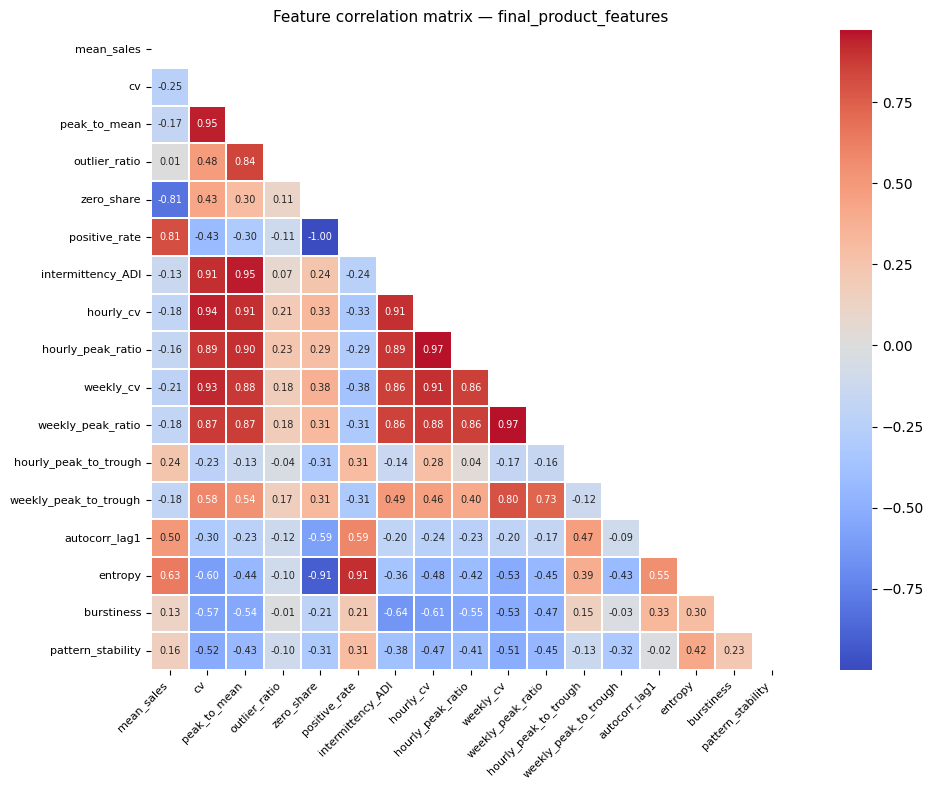

In [22]:
corr_cols = ['mean_sales', 'cv', 'peak_to_mean', 'outlier_ratio',
             'zero_share', 'positive_rate', 'intermittency_ADI',
             'hourly_cv', 'hourly_peak_ratio', 'weekly_cv', 'weekly_peak_ratio',
             'hourly_peak_to_trough', 'weekly_peak_to_trough',
             'autocorr_lag1', 'entropy', 'burstiness', 'pattern_stability']

corr_cols = [c for c in corr_cols if c in final_product_features.columns]
corr_matrix = final_product_features[corr_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm',
            fmt='.2f', center=0, annot_kws={'size': 7},
            linewidths=0.3, square=True)
plt.title('Feature correlation matrix — final_product_features', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

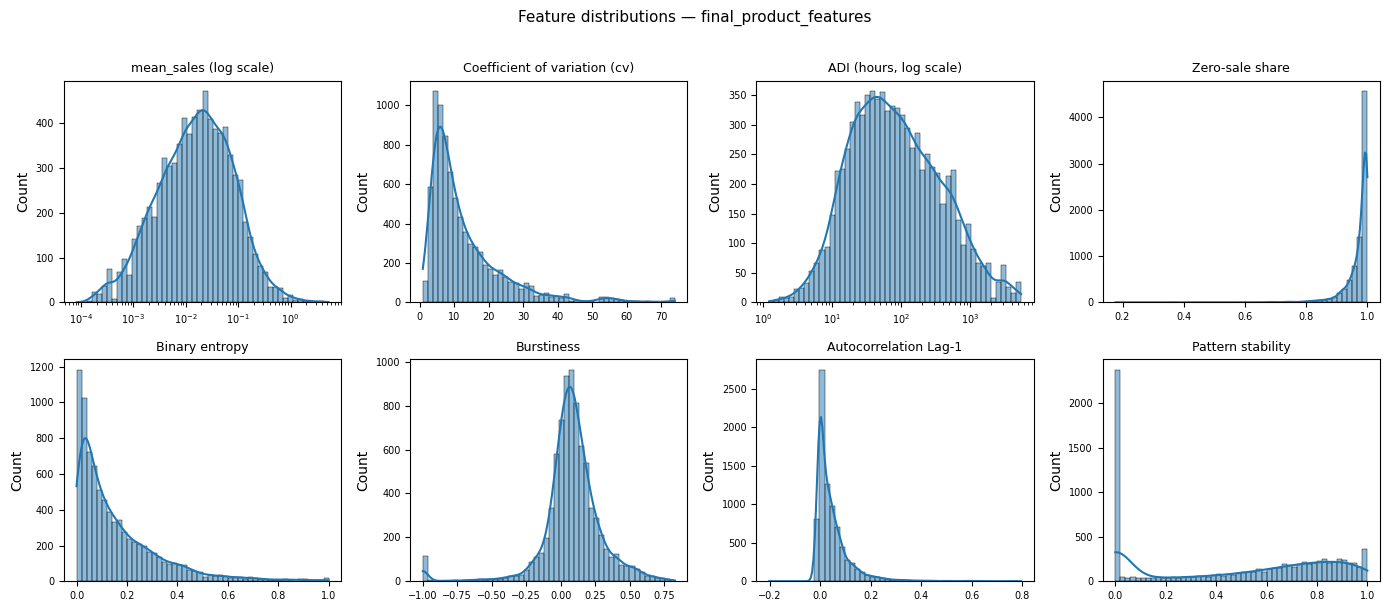

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

plot_pairs = [
    ('mean_sales',        'mean_sales (log scale)', True),
    ('cv',                'Coefficient of variation (cv)', False),
    ('intermittency_ADI', 'ADI (hours, log scale)', True),
    ('zero_share',        'Zero-sale share', False),
    ('entropy',           'Binary entropy', False),
    ('burstiness',        'Burstiness', False),
    ('autocorr_lag1',     'Autocorrelation Lag-1', False),
    ('pattern_stability', 'Pattern stability', False),
]

for ax, (col, title, log) in zip(axes.flatten(), plot_pairs):
    if col in final_product_features.columns:
        data = final_product_features[col].dropna()
        if log:
            data = data[data > 0]
        sns.histplot(data, bins=50, kde=True, ax=ax, log_scale=log)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('')
        ax.tick_params(labelsize=7)

plt.suptitle('Feature distributions — final_product_features', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [24]:
from scipy.stats import kruskal
hourly_sales = df.groupby('date').sales.sum().reset_index()
hourly_sales['hour'] = hourly_sales['date'].dt.hour
groups = [group['sales'].values for _, group in hourly_sales.groupby('hour')]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis p-value: {p:.2e}")  # должно быть << 0.05

Kruskal-Wallis p-value: 0.00e+00


## Chapter 3. Summary and Modelling Implications

The exploratory analysis and feature engineering carried out in this notebook establish the following key facts about the dataset. Each of these findings directly shapes the design of the anomaly detection pipeline:

| Finding | Modelling implication |
|---------|-----------------------|
| Median zero-sale share ≈ 98.9% | Models must handle extreme sparsity; standard MSE loss is unsuitable |
| Median Average Demand Interval (ADI) ≈ 74 hours | Per-product historical baseline is required to define “normal” behaviour |
| **Strong intraday seasonality** (two pronounced daily peaks: 11:00–13:00 and 17:00–18:00), statistically confirmed by Kruskal-Wallis test (**p = 0.00e+00**) | `hour_of_day` is a mandatory feature in all models; TCN uses 168-hour lookback window |
| Weak intraweek seasonality relative to intraday | Day-of-week is included but given lower importance than hour |
| High cross-category heterogeneity in ADI and zero-share | Contamination parameter in Isolation Forest is calibrated based on the observed anomaly rate rather than a generic default |
| Right-skewed sales distribution (skewness ≈ 13.75) | Huber loss is used in LightGBM and TCN instead of MSE |
| Stock availability as a major confounding factor | All models apply mandatory business filters: `stocks > 0` and `hour ∈ [7, 22]` |